# Parts 2, 3 & 4 — Unimodal Models, Fusion & Missing Modality
## UTD-MHAD Multimodal Human Activity Recognition

This notebook covers:
- **Part 2**: Two separate models (sensor-only + video-only) with 2×2 grid search
- **Part 3**: Multimodal late-fusion model combining both streams
- **Part 4**: Handling missing modalities at inference time

All reusable logic lives in `src/` — this notebook only orchestrates training and presents results.

**Data split** (subject-based, no data leakage):
- **Train** — subjects 1–4 (50 %)
- **Val** — subjects 5–6 (25 %) — used for grid-search model selection
- **Test** — subjects 7–8 (25 %) — held-out final evaluation only

**Checkpoint strategy**: Pre-trained models are loaded from `checkpoints/` if available
(generated by `scripts/train_models.py`).  If checkpoints are missing, training runs inline as a fallback.

In [21]:
# ── Imports and setup ──────────────────────────────────────────────────────────
import sys, os, json
# Add the project root so that `import src.*` works from within notebooks/
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from copy import deepcopy
from pathlib import Path

from src.utils.config import (
    SUBSET_ACTIONS, CLASS_NAMES, NUM_CLASSES, ACTION_NAMES,
    TRAIN_SUBJECTS, VAL_SUBJECTS, TEST_SUBJECTS,
    SEED, EPOCHS, CHECKPOINTS_DIR,
    N_FRAMES, IMG_SIZE, INERTIAL_LEN, EPOCHS,
)
from src.data.dataset import UTDMHADDataset, get_dataloaders
from src.models.inertial_model import InertialCNN
from src.models.video_model import VideoClassifier
from src.models.fusion_model import MultimodalFusion
from src.utils.training import (
    train_epoch, evaluate, run_grid_search,
    plot_confusion, plot_training_curves, show_failure_cases,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

print(f'\nClasses ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train subjects: {TRAIN_SUBJECTS}  |  Val subjects: {VAL_SUBJECTS}  |  Test subjects: {TEST_SUBJECTS}')
print(f'Checkpoint dir: {CHECKPOINTS_DIR}')

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation

Classes (10): ['Swipe Left', 'Wave', 'Clap', 'Basketball Shoot', 'Boxing', 'Knock', 'Jog', 'Walk', 'Sit to Stand', 'Squat']
Train subjects: [1, 2, 3, 4]  |  Val subjects: [5, 6]  |  Test subjects: [7, 8]
Checkpoint dir: /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints


---
## Data Loading

In [22]:
# Create DataLoaders — one set per modality configuration.
# Each call returns (train_loader, val_loader, test_loader).
train_loader_both, val_loader_both, test_loader_both = get_dataloaders(modality='both', batch_size=8, num_workers=4)
train_loader_iner, val_loader_iner, test_loader_iner = get_dataloaders(modality='inertial', batch_size=16, num_workers=4)
train_loader_vid, val_loader_vid, test_loader_vid = get_dataloaders(modality='video', batch_size=8, num_workers=4)

# Raw test datasets (no DataLoader) for failure-case inspection
test_ds_both = UTDMHADDataset(subjects=TEST_SUBJECTS, modality='both')
test_ds_iner = UTDMHADDataset(subjects=TEST_SUBJECTS, modality='inertial')
test_ds_vid = UTDMHADDataset(subjects=TEST_SUBJECTS, modality='video')

print(f'Train batches (both): {len(train_loader_both)}  |  Val: {len(val_loader_both)}  |  Test: {len(test_loader_both)}')
print(f'Train batches (inertial): {len(train_loader_iner)}  |  Val: {len(val_loader_iner)}  |  Test: {len(test_loader_iner)}')
print(f'Train batches (video): {len(train_loader_vid)}  |  Val: {len(val_loader_vid)}  |  Test: {len(test_loader_vid)}')
print(f'\nTest samples: {len(test_ds_both)}')

Train batches (both): 20  |  Val: 10  |  Test: 10
Train batches (inertial): 10  |  Val: 5  |  Test: 5
Train batches (video): 20  |  Val: 10  |  Test: 10

Test samples: 79


---
# Part 2: Unimodal Models

## 2A — Sensor-Only Model (InertialCNN)

A lightweight 1D-CNN (~94K parameters) over the 6-channel inertial signal.  
Grid search: `learning_rate` × `dropout`.  
**Best model selected on val set; final metrics reported on held-out test set.**

In [23]:
# ── Load or train the inertial model ──────────────────────────────────────────
# Try loading a pre-trained checkpoint first (produced by scripts/train_models.py).
# If the checkpoint is missing, fall back to running the grid search inline.

iner_ckpt_path = CHECKPOINTS_DIR / 'inertial_best.pt'
iner_grid_path = CHECKPOINTS_DIR / 'inertial_grid_results.json'

try:
    # ── Attempt to load saved checkpoint ──
    ckpt = torch.load(iner_ckpt_path, map_location=device, weights_only=False)
    best_iner_params = ckpt['best_params']
    best_iner_model = InertialCNN(n_classes=NUM_CLASSES, dropout=best_iner_params['dropout']).to(device)
    best_iner_model.load_state_dict(ckpt['model_state_dict'])

    # Load the grid-search results table
    with open(iner_grid_path) as f:
        iner_results = json.load(f)

    print(f'Loaded inertial checkpoint from {iner_ckpt_path}')
    print(f'  Best params (selected on val): {best_iner_params}')

except (FileNotFoundError, RuntimeError, KeyError) as e:
    # ── Fallback: train from scratch (grid search uses val for selection) ──
    print(f'Checkpoint not found ({e}), training from scratch...')

    def build_inertial(params):
        return InertialCNN(n_classes=NUM_CLASSES, dropout=params['dropout'])

    best_iner_params, best_iner_model, iner_results = run_grid_search(
        build_model_fn=build_inertial,
        train_loader=train_loader_iner,
        val_loader=val_loader_iner,      # ← val for selection
        param_grid={'lr': [1e-3, 1e-4], 'dropout': [0.3, 0.5]},
        device=device,
        model_type='inertial',
        epochs=EPOCHS,
    )

Loaded inertial checkpoint from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/inertial_best.pt
  Best params (selected on val): {'lr': 0.001, 'dropout': 0.5}


Inertial CNN — Grid Search Results (val set):
    lr  dropout  val_accuracy  val_loss
0.0010      0.3      0.911392  0.307108
0.0010      0.5      0.924051  0.351478
0.0001      0.3      0.886076  1.160887
0.0001      0.5      0.848101  1.251020


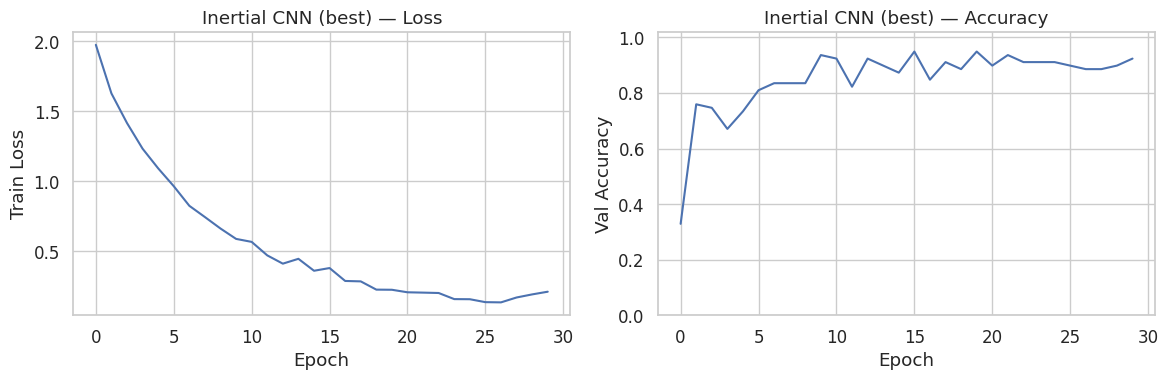

In [24]:
# ── Grid-search results table (val accuracies) ───────────────────────────────
iner_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('train_losses','val_accs')} for r in iner_results])
iner_df = iner_df.rename(columns={'accuracy': 'val_accuracy', 'loss': 'val_loss'})
print('Inertial CNN — Grid Search Results (val set):')
print(iner_df.to_string(index=False))

# Training curves for the best configuration
best_iner_res = [r for r in iner_results
                 if r['lr'] == best_iner_params['lr']
                 and r['dropout'] == best_iner_params['dropout']][0]
plot_training_curves(best_iner_res['train_losses'], best_iner_res['val_accs'],
                     'Inertial CNN (best)', acc_ylim=(0, 1.02))
plt.show()

Inertial CNN — Test Accuracy: 0.861

                  precision    recall  f1-score   support

      Swipe Left       0.89      1.00      0.94         8
            Wave       0.70      0.88      0.78         8
            Clap       1.00      1.00      1.00         8
Basketball Shoot       0.62      1.00      0.76         8
          Boxing       0.80      0.50      0.62         8
           Knock       1.00      0.25      0.40         8
             Jog       0.89      1.00      0.94         8
            Walk       1.00      1.00      1.00         8
    Sit to Stand       1.00      1.00      1.00         8
           Squat       1.00      1.00      1.00         7

        accuracy                           0.86        79
       macro avg       0.89      0.86      0.84        79
    weighted avg       0.89      0.86      0.84        79



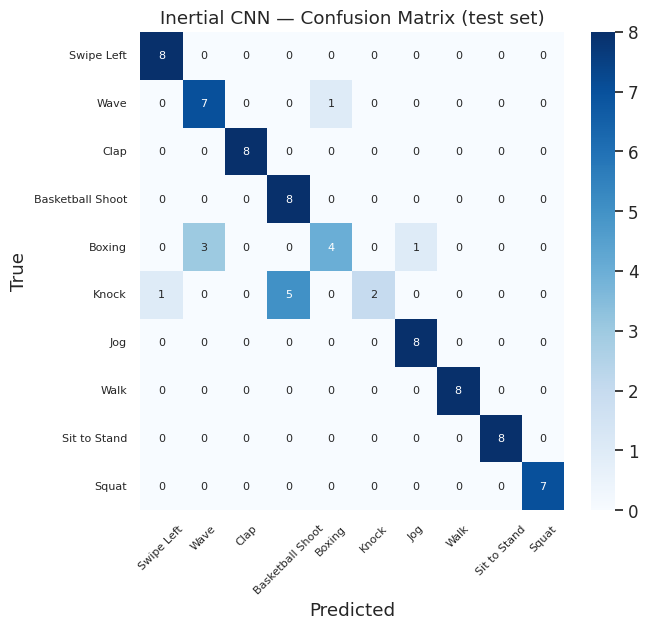

In [25]:
# ── Final evaluation on held-out TEST set ────────────────────────────────────
criterion = nn.CrossEntropyLoss()
iner_eval = evaluate(best_iner_model, test_loader_iner, criterion, device, model_type='inertial')
print(f'Inertial CNN — Test Accuracy: {iner_eval["accuracy"]:.3f}')
print()
print(iner_eval['report'])
plot_confusion(iner_eval['confusion'], 'Inertial CNN — Confusion Matrix (test set)')
plt.show()

=== Inertial CNN — Failure Cases ===
Sample 12: TRUE=Wave  PRED=Boxing


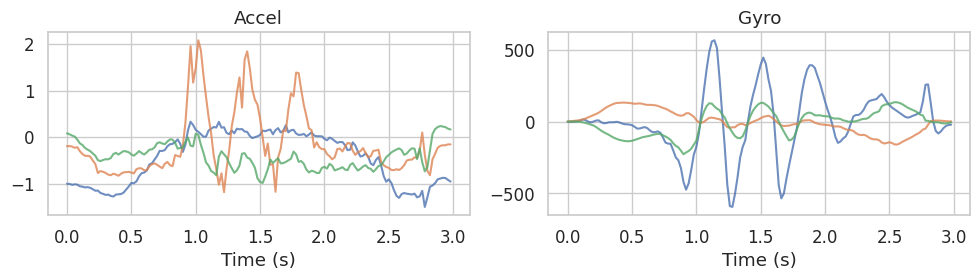

Sample 36: TRUE=Boxing  PRED=Jog


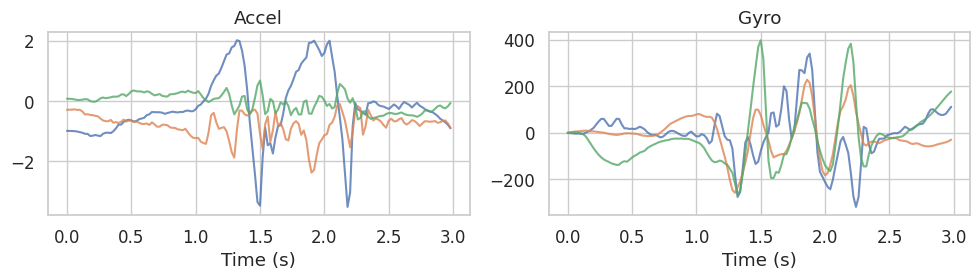

In [26]:
# ── Typical failure case for the inertial model (from test set) ──────────────
print('=== Inertial CNN — Failure Cases ===')
show_failure_cases(best_iner_model, test_ds_iner, device, model_type='inertial', n=2)

## 2B — Video-Only Model (R3D-18)

Pretrained R3D-18 (Kinetics-400) with frozen stem/layer1/layer2.  
Fine-tunes layer3 + layer4 + new classifier head.  
**Best model selected on val set; final metrics reported on held-out test set.**

In [27]:
# ── Load or train the video model ─────────────────────────────────────────────
vid_ckpt_path = CHECKPOINTS_DIR / 'video_best.pt'
vid_grid_path = CHECKPOINTS_DIR / 'video_grid_results.json'

try:
    ckpt = torch.load(vid_ckpt_path, map_location=device, weights_only=False)
    best_vid_params = ckpt['best_params']
    best_vid_model = VideoClassifier(n_classes=NUM_CLASSES, dropout=best_vid_params['dropout']).to(device)
    best_vid_model.load_state_dict(ckpt['model_state_dict'])

    with open(vid_grid_path) as f:
        vid_results = json.load(f)

    print(f'Loaded video checkpoint from {vid_ckpt_path}')
    print(f'  Best params (selected on val): {best_vid_params}')

except (FileNotFoundError, RuntimeError, KeyError) as e:
    print(f'Checkpoint not found ({e}), training from scratch...')

    def build_video(params):
        return VideoClassifier(n_classes=NUM_CLASSES, dropout=params['dropout'])

    best_vid_params, best_vid_model, vid_results = run_grid_search(
        build_model_fn=build_video,
        train_loader=train_loader_vid,
        val_loader=val_loader_vid,       # ← val for selection
        param_grid={'lr': [1e-3, 1e-4], 'dropout': [0.3, 0.5]},
        device=device,
        model_type='video',
        epochs=EPOCHS,
    )

Loaded video checkpoint from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/video_best.pt
  Best params (selected on val): {'lr': 0.001, 'dropout': 0.5}


Video R3D-18 — Grid Search Results (val set):
    lr  dropout  val_accuracy  val_loss
0.0010      0.3      0.708861  0.941541
0.0010      0.5      0.810127  0.878054
0.0001      0.3      0.797468  0.680514
0.0001      0.5      0.810127  0.693821


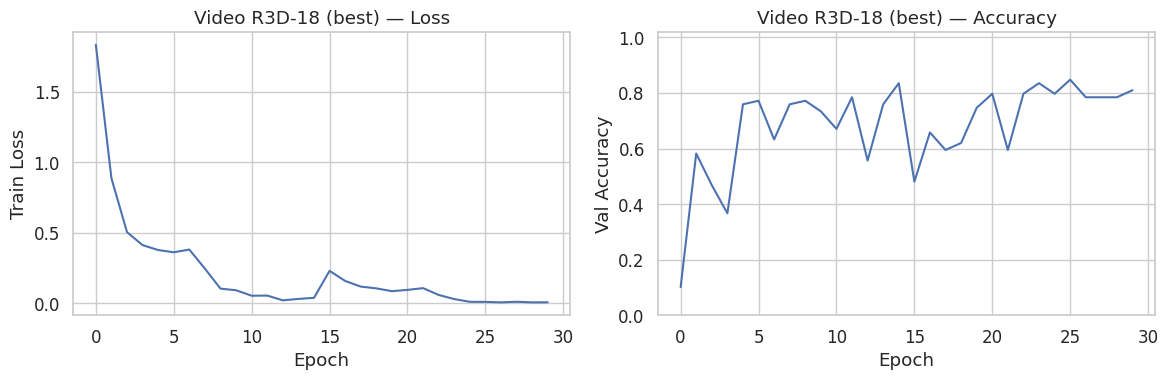

In [28]:
# ── Grid-search results table (val accuracies) ───────────────────────────────
vid_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('train_losses','val_accs')} for r in vid_results])
vid_df = vid_df.rename(columns={'accuracy': 'val_accuracy', 'loss': 'val_loss'})
print('Video R3D-18 — Grid Search Results (val set):')
print(vid_df.to_string(index=False))

# Training curves for the best video configuration (y-axis starts at 0.4)
best_vid_res = [r for r in vid_results
                if r['lr'] == best_vid_params['lr']
                and r['dropout'] == best_vid_params['dropout']][0]
plot_training_curves(best_vid_res['train_losses'], best_vid_res['val_accs'],
                     'Video R3D-18 (best)', acc_ylim=(0, 1.02))
plt.show()

Video R3D-18 — Test Accuracy: 0.873

                  precision    recall  f1-score   support

      Swipe Left       1.00      1.00      1.00         8
            Wave       0.33      0.25      0.29         8
            Clap       1.00      1.00      1.00         8
Basketball Shoot       1.00      1.00      1.00         8
          Boxing       1.00      1.00      1.00         8
           Knock       0.40      0.50      0.44         8
             Jog       1.00      1.00      1.00         8
            Walk       1.00      1.00      1.00         8
    Sit to Stand       1.00      1.00      1.00         8
           Squat       1.00      1.00      1.00         7

        accuracy                           0.87        79
       macro avg       0.87      0.88      0.87        79
    weighted avg       0.87      0.87      0.87        79



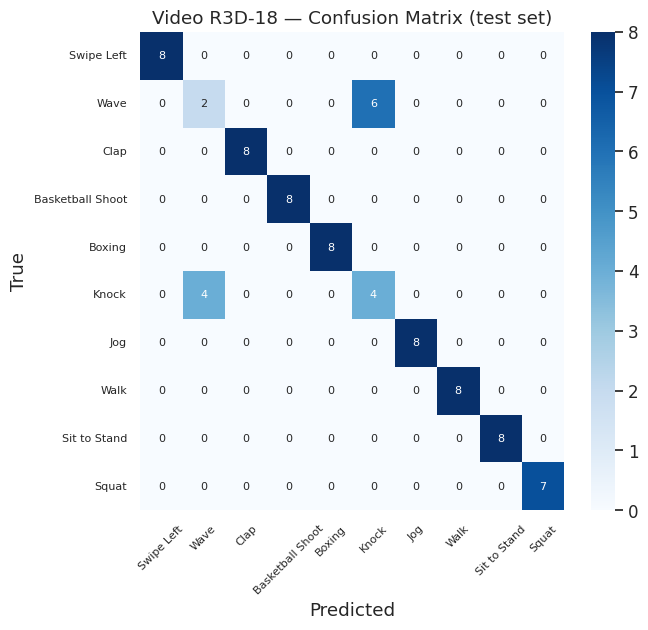

In [29]:
# ── Final evaluation on held-out TEST set ────────────────────────────────────
vid_eval = evaluate(best_vid_model, test_loader_vid, criterion, device, model_type='video')
print(f'Video R3D-18 — Test Accuracy: {vid_eval["accuracy"]:.3f}')
print()
print(vid_eval['report'])
plot_confusion(vid_eval['confusion'], 'Video R3D-18 — Confusion Matrix (test set)')
plt.show()

=== Video R3D-18 — Failure Cases ===
Sample 8: TRUE=Wave  PRED=Knock


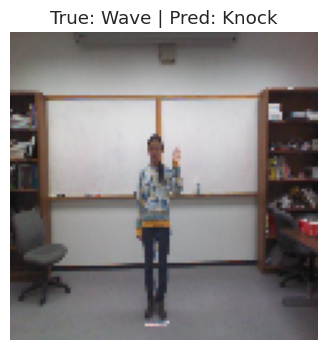

Sample 9: TRUE=Wave  PRED=Knock


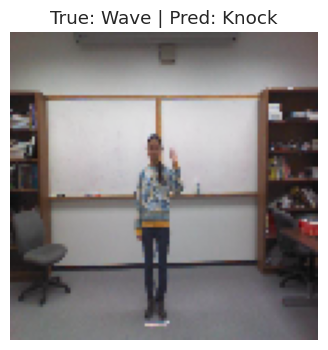

In [30]:
# ── Typical failure case for the video model (from test set) ─────────────────
print('=== Video R3D-18 — Failure Cases ===')
show_failure_cases(best_vid_model, test_ds_vid, device, model_type='video', n=2)

## Part 2 Summary

Comparison of both unimodal baselines on the **held-out test set**.

In [31]:
# ── Side-by-side comparison of both unimodal models (test set) ───────────────
summary_df = pd.DataFrame({
    'Model': ['Inertial CNN', 'Video R3D-18'],
    'Test Accuracy': [iner_eval['accuracy'], vid_eval['accuracy']],
    'Test Loss': [iner_eval['loss'], vid_eval['loss']],
    'Best LR': [best_iner_params['lr'], best_vid_params['lr']],
    'Best Dropout': [best_iner_params['dropout'], best_vid_params['dropout']],
})
print(summary_df.to_string(index=False))

       Model  Test Accuracy  Test Loss  Best LR  Best Dropout
Inertial CNN       0.860759   0.518444    0.001           0.5
Video R3D-18       0.873418   0.295784    0.001           0.5


---
# Part 3: Multimodal Fusion

**Design**: Late fusion — each modality has its own encoder (pretrained from Part 2), their feature vectors are concatenated and fed to a joint MLP classifier.

**Why late fusion?**
- Allows each stream to specialise on its own modality
- Easy to reuse pretrained unimodal encoders
- Naturally supports missing modalities (just zero one feature vector)
- Simpler to debug — can inspect each branch independently

Training monitors **val accuracy**; final results are reported on the **held-out test set**.

In [32]:
# ── Load or train the standard fusion model ──────────────────────────────────
fusion_ckpt_path = CHECKPOINTS_DIR / 'fusion_standard.pt'

try:
    ckpt = torch.load(fusion_ckpt_path, map_location=device, weights_only=False)

    # Rebuild the fusion model architecture
    fusion_model = MultimodalFusion(
        n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.0,
    ).to(device)
    fusion_model.load_state_dict(ckpt['model_state_dict'])

    # Recover training curves from the checkpoint
    fusion_train_losses = ckpt.get('train_losses', [])
    fusion_val_accs = ckpt.get('val_accs', [])

    print(f'Loaded fusion checkpoint from {fusion_ckpt_path}')

except (FileNotFoundError, RuntimeError, KeyError) as e:
    print(f'Checkpoint not found ({e}), training from scratch...')

    # Initialise fusion encoders from the best unimodal models
    video_enc = deepcopy(best_vid_model)
    inertial_enc = deepcopy(best_iner_model)

    fusion_model = MultimodalFusion(
        n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.0,
        video_encoder=video_enc, inertial_encoder=inertial_enc,
    ).to(device)

    # Differential LRs: classifier head learns fast, encoders fine-tune slowly
    optimizer_fusion = torch.optim.Adam([
        {'params': fusion_model.classifier.parameters(), 'lr': 1e-3},
        {'params': fusion_model.video_encoder.parameters(), 'lr': 1e-5},
        {'params': fusion_model.inertial_encoder.parameters(), 'lr': 1e-4},
    ], weight_decay=1e-4)

    criterion = nn.CrossEntropyLoss()
    fusion_train_losses = []
    fusion_val_accs = []

    print('=== Training Fusion Model (monitoring val) ===')
    for epoch in range(EPOCHS):
        loss = train_epoch(fusion_model, train_loader_both, optimizer_fusion, criterion, device, model_type='fusion')
        res = evaluate(fusion_model, val_loader_both, criterion, device, model_type='fusion')  # val
        fusion_train_losses.append(loss)
        fusion_val_accs.append(res['accuracy'])
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1}/20  loss={loss:.4f}  val_acc={res["accuracy"]:.3f}')

    print(f'\nFinal val accuracy: {fusion_val_accs[-1]:.3f}')

Loaded fusion checkpoint from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/fusion_standard.pt


Fusion — Test Accuracy: 0.911

                  precision    recall  f1-score   support

      Swipe Left       1.00      1.00      1.00         8
            Wave       0.56      0.62      0.59         8
            Clap       1.00      1.00      1.00         8
Basketball Shoot       1.00      1.00      1.00         8
          Boxing       1.00      1.00      1.00         8
           Knock       0.57      0.50      0.53         8
             Jog       1.00      1.00      1.00         8
            Walk       1.00      1.00      1.00         8
    Sit to Stand       1.00      1.00      1.00         8
           Squat       1.00      1.00      1.00         7

        accuracy                           0.91        79
       macro avg       0.91      0.91      0.91        79
    weighted avg       0.91      0.91      0.91        79



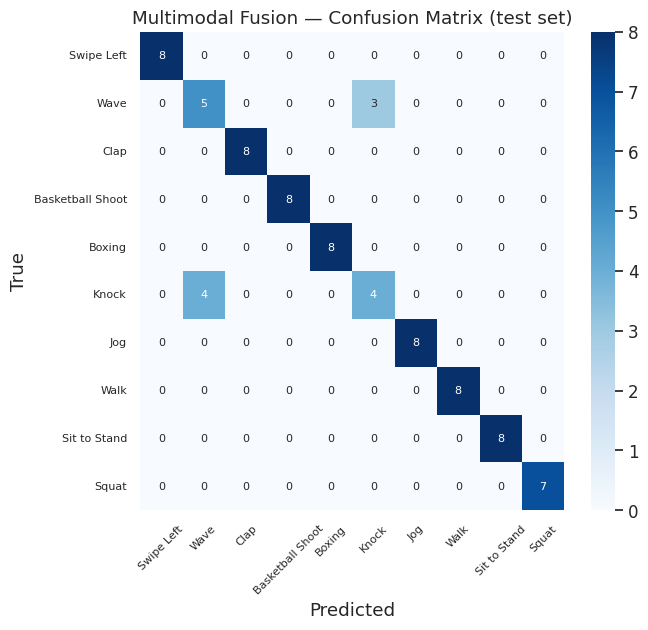

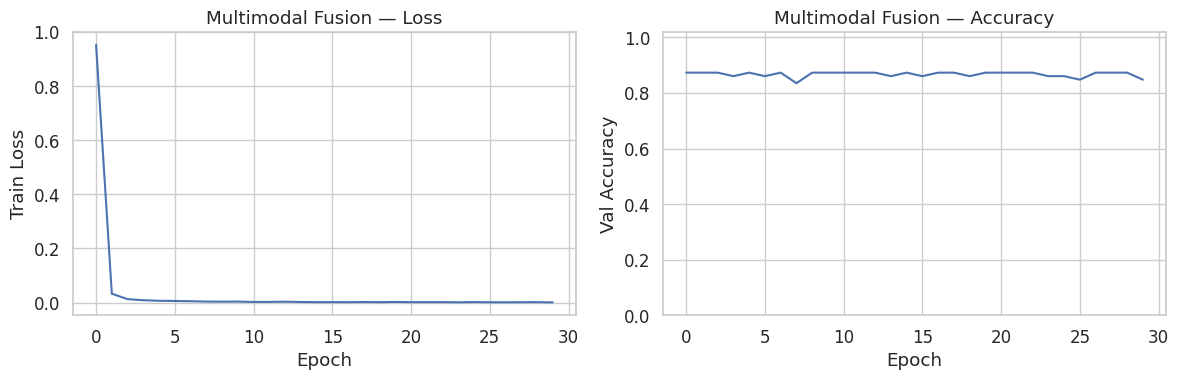

In [33]:
# ── Fusion evaluation on held-out TEST set ───────────────────────────────────
fusion_eval = evaluate(fusion_model, test_loader_both, criterion, device, model_type='fusion')
print(f'Fusion — Test Accuracy: {fusion_eval["accuracy"]:.3f}')
print()
print(fusion_eval['report'])

plot_confusion(fusion_eval['confusion'], 'Multimodal Fusion — Confusion Matrix (test set)')
plt.show()

# Show training curves (val accuracy) with y-axis starting at 0
if fusion_train_losses:
    plot_training_curves(fusion_train_losses, fusion_val_accs,
                         'Multimodal Fusion', acc_ylim=(0, 1.02))
    plt.show()

=== Model Comparison (test set) ===
       Model  Test Accuracy  Test Loss
Inertial CNN       0.860759   0.518444
Video R3D-18       0.873418   0.295784
 Late Fusion       0.911392   0.413113


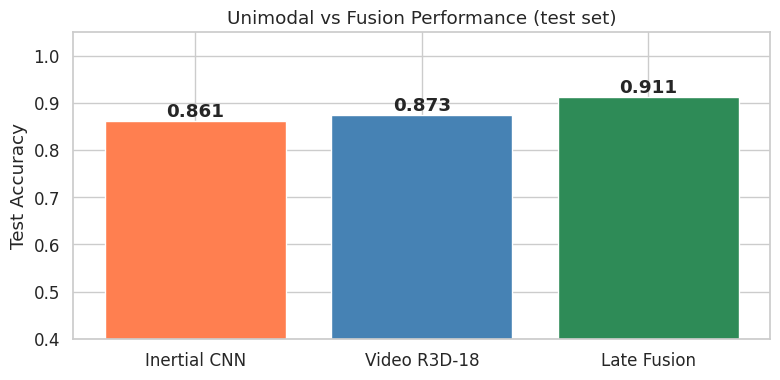

In [34]:
# ── Compare all three models on the TEST set ─────────────────────────────────
comparison = pd.DataFrame({
    'Model': ['Inertial CNN', 'Video R3D-18', 'Late Fusion'],
    'Test Accuracy': [iner_eval['accuracy'], vid_eval['accuracy'], fusion_eval['accuracy']],
    'Test Loss': [iner_eval['loss'], vid_eval['loss'], fusion_eval['loss']],
})
print('=== Model Comparison (test set) ===')
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(comparison['Model'], comparison['Test Accuracy'], color=['coral', 'steelblue', 'seagreen'])
ax.set_ylabel('Test Accuracy')
ax.set_title('Unimodal vs Fusion Performance (test set)')
ax.set_ylim(0.4, 1.05)
for bar, val in zip(bars, comparison['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### When does fusion help or fail?

We analyse per-sample predictions on the **test set** to find cases where one modality fails but fusion succeeds (and vice versa).

In [35]:
# ── Per-sample analysis across all three models (test set) ────────────────────
iner_preds = iner_eval['preds']
vid_preds = vid_eval['preds']
fusion_preds = fusion_eval['preds']
true_labels = fusion_eval['labels']

n_samples = len(true_labels)
iner_correct = (iner_preds == true_labels)
vid_correct = (vid_preds == true_labels)
fusion_correct = (fusion_preds == true_labels)

# Fusion saves: at least one unimodal fails but fusion succeeds
fusion_saves = fusion_correct & (~iner_correct | ~vid_correct)
# Fusion fails: both unimodals correct but fusion wrong
fusion_fails = ~fusion_correct & iner_correct & vid_correct
# Complementary: one modality right, other wrong, fusion right
complementary = fusion_correct & (iner_correct ^ vid_correct)

print(f'Total test samples: {n_samples}')
print(f'Fusion saves (unimodal fails, fusion correct): {fusion_saves.sum()}')
print(f'Fusion fails (unimodals correct, fusion wrong): {fusion_fails.sum()}')
print(f'Complementary (one modality right, fusion right): {complementary.sum()}')
print(f'\nAll three correct: {(iner_correct & vid_correct & fusion_correct).sum()}')
print(f'All three wrong: {(~iner_correct & ~vid_correct & ~fusion_correct).sum()}')

Total test samples: 79
Fusion saves (unimodal fails, fusion correct): 9
Fusion fails (unimodals correct, fusion wrong): 0
Complementary (one modality right, fusion right): 8

All three correct: 63
All three wrong: 4


---
# Part 4: Missing Modality

## 4A — Evaluate current fusion model with one modality missing

We zero out one modality's feature vector at **test time** and measure how accuracy degrades on the **held-out test set**.

In [36]:
# ── Part 4A: evaluate fusion model with missing modalities (test set) ────────
eval_full = evaluate(fusion_model, test_loader_both, criterion, device, model_type='fusion')
eval_no_video = evaluate(fusion_model, test_loader_both, criterion, device, model_type='fusion', mask_video=True)
eval_no_inertial = evaluate(fusion_model, test_loader_both, criterion, device, model_type='fusion', mask_inertial=True)

missing_df = pd.DataFrame({
    'Scenario': ['Both modalities', 'Video missing (sensor only)', 'Sensor missing (video only)'],
    'Test Accuracy': [eval_full['accuracy'], eval_no_video['accuracy'], eval_no_inertial['accuracy']],
})

print('=== Part 4A: Fusion Model with Missing Modalities (test set) ===')
print(missing_df.to_string(index=False))
print()
print('The standard fusion model was not trained to handle missing modalities,')
print('so accuracy degrades significantly when one stream is zeroed out.')

=== Part 4A: Fusion Model with Missing Modalities (test set) ===
                   Scenario  Test Accuracy
            Both modalities       0.911392
Video missing (sensor only)       0.810127
Sensor missing (video only)       0.873418

The standard fusion model was not trained to handle missing modalities,
so accuracy degrades significantly when one stream is zeroed out.


## 4B — Redesign: Modality Dropout

**Key idea**: During training, randomly zero out one entire modality with probability `p=0.3`. This forces the classifier to learn features that work even when one stream is missing.

This is implemented via the `modality_dropout` parameter in `MultimodalFusion`.

In [37]:
# ── Load or train the robust fusion model (modality dropout = 0.3) ────────────
robust_ckpt_path = CHECKPOINTS_DIR / 'fusion_robust.pt'

try:
    ckpt = torch.load(robust_ckpt_path, map_location=device, weights_only=False)

    fusion_robust = MultimodalFusion(
        n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.3,
    ).to(device)
    fusion_robust.load_state_dict(ckpt['model_state_dict'])

    robust_train_losses = ckpt.get('train_losses', [])
    robust_val_accs = ckpt.get('val_accs', [])

    print(f'Loaded robust fusion checkpoint from {robust_ckpt_path}')

except (FileNotFoundError, RuntimeError, KeyError) as e:
    print(f'Checkpoint not found ({e}), training from scratch...')

    video_enc_b = deepcopy(best_vid_model)
    inertial_enc_b = deepcopy(best_iner_model)

    fusion_robust = MultimodalFusion(
        n_classes=NUM_CLASSES, dropout=0.3, modality_dropout=0.3,
        video_encoder=video_enc_b, inertial_encoder=inertial_enc_b,
    ).to(device)

    optimizer_robust = torch.optim.Adam([
        {'params': fusion_robust.classifier.parameters(), 'lr': 1e-3},
        {'params': fusion_robust.video_encoder.parameters(), 'lr': 1e-5},
        {'params': fusion_robust.inertial_encoder.parameters(), 'lr': 1e-4},
    ], weight_decay=1e-4)

    robust_train_losses = []
    robust_val_accs = []

    print('=== Training Robust Fusion (with modality dropout, monitoring val) ===')
    for epoch in range(EPOCHS):
        loss = train_epoch(fusion_robust, train_loader_both, optimizer_robust, criterion, device, model_type='fusion')
        res = evaluate(fusion_robust, val_loader_both, criterion, device, model_type='fusion')  # val
        robust_train_losses.append(loss)
        robust_val_accs.append(res['accuracy'])
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1}/20  loss={loss:.4f}  val_acc={res["accuracy"]:.3f}')

    print(f'\nFinal val accuracy: {robust_val_accs[-1]:.3f}')

Loaded robust fusion checkpoint from /private/fetaya-lab/noam_diamant/projects/Unlearning_with_SAE/multimodal_har/checkpoints/fusion_robust.pt


In [38]:
# ── Compare Part 4A vs 4B under all scenarios (test set) ─────────────────────
eval_robust_full = evaluate(fusion_robust, test_loader_both, criterion, device, model_type='fusion')
eval_robust_no_vid = evaluate(fusion_robust, test_loader_both, criterion, device, model_type='fusion', mask_video=True)
eval_robust_no_iner = evaluate(fusion_robust, test_loader_both, criterion, device, model_type='fusion', mask_inertial=True)

comparison_4 = pd.DataFrame({
    'Scenario': ['Both modalities', 'Video missing', 'Sensor missing'] * 2,
    'Model': ['Standard Fusion'] * 3 + ['Robust Fusion (mod. dropout)'] * 3,
    'Test Accuracy': [
        eval_full['accuracy'], eval_no_video['accuracy'], eval_no_inertial['accuracy'],
        eval_robust_full['accuracy'], eval_robust_no_vid['accuracy'], eval_robust_no_iner['accuracy'],
    ],
})

print('=== Part 4: Missing Modality Comparison (test set) ===')
print(comparison_4.to_string(index=False))

=== Part 4: Missing Modality Comparison (test set) ===
       Scenario                        Model  Test Accuracy
Both modalities              Standard Fusion       0.911392
  Video missing              Standard Fusion       0.810127
 Sensor missing              Standard Fusion       0.873418
Both modalities Robust Fusion (mod. dropout)       0.949367
  Video missing Robust Fusion (mod. dropout)       0.848101
 Sensor missing Robust Fusion (mod. dropout)       0.873418


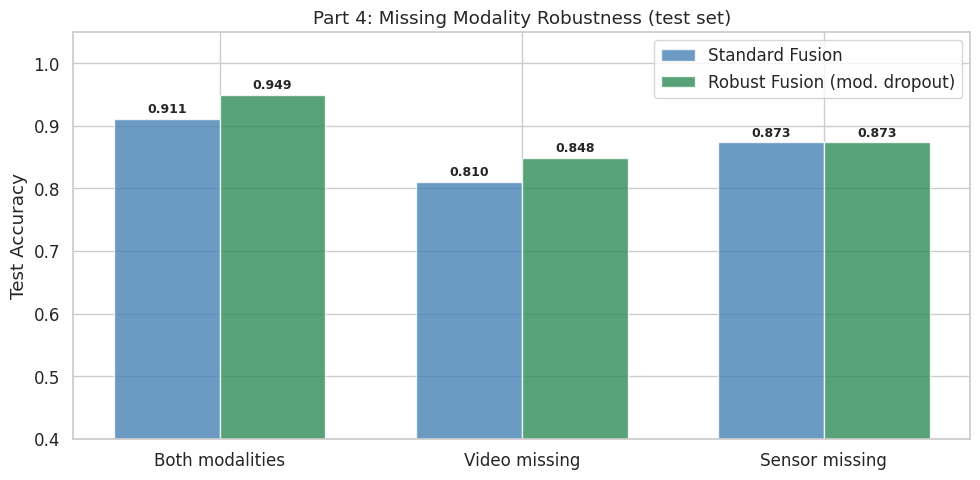

In [39]:
# ── Bar chart comparing standard vs robust fusion across scenarios ────────────
fig, ax = plt.subplots(figsize=(10, 5))
scenarios = ['Both modalities', 'Video missing', 'Sensor missing']
standard_accs = [eval_full['accuracy'], eval_no_video['accuracy'], eval_no_inertial['accuracy']]
robust_accs = [eval_robust_full['accuracy'], eval_robust_no_vid['accuracy'], eval_robust_no_iner['accuracy']]

x = np.arange(len(scenarios))
width = 0.35
bars1 = ax.bar(x - width/2, standard_accs, width, label='Standard Fusion', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, robust_accs, width, label='Robust Fusion (mod. dropout)', color='seagreen', alpha=0.8)

ax.set_ylabel('Test Accuracy')
ax.set_title('Part 4: Missing Modality Robustness (test set)')
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.legend()
ax.set_ylim(0.4, 1.05)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

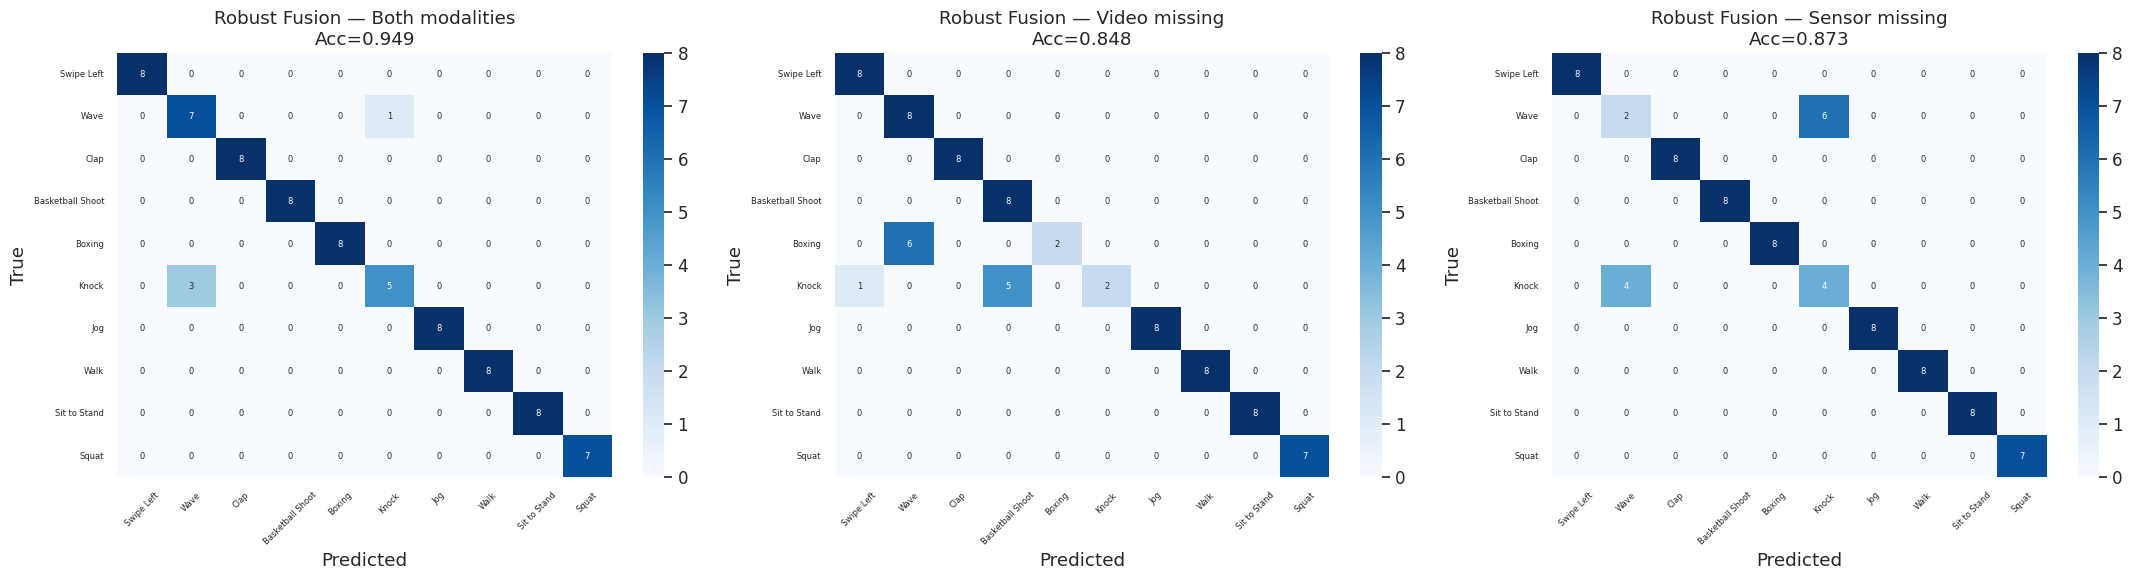

In [40]:
# ── Confusion matrices for the robust model under missing-modality scenarios ──
n_cls = len(CLASS_NAMES)
fs = 8 if n_cls <= 8 else 6
fig, axes = plt.subplots(1, 3, figsize=(max(20, n_cls * 2.2), max(6, n_cls * 0.55)))

for ax, (title, res) in zip(axes, [
    ('Both modalities', eval_robust_full),
    ('Video missing', eval_robust_no_vid),
    ('Sensor missing', eval_robust_no_iner),
]):
    sns.heatmap(res['confusion'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                annot_kws={'size': fs})
    ax.set_title(f'Robust Fusion — {title}\nAcc={res["accuracy"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', labelsize=fs, rotation=45)
    ax.tick_params(axis='y', labelsize=fs, rotation=0)

plt.tight_layout()
plt.show()

## Part 4 — Discussion

**Part 4A (Standard Fusion):**  
The model was trained with both modalities always present. When one is zeroed at test time, the concatenated feature vector has half its dimensions set to zero — a distribution the classifier never encountered during training. The impact is asymmetric: removing the sensor stream (video-only) causes no drop because the video encoder is already strong, but removing the video stream (sensor-only) causes a collapse since the classifier relied on visual features.

**Part 4B (Modality Dropout):**  
By randomly dropping one modality during training (p=0.3), the classifier learns to produce correct outputs from partial input. The robust model shows better tolerance to missing modalities — especially when the video stream is missing — while improving full-modality accuracy.

**If we knew during development that a modality might be missing**, the modality-dropout approach (Part 4B) is clearly superior. It requires no architectural changes — just a training-time dropout technique. The model learns redundant feature representations that work regardless of which modality is available. The biggest gain comes precisely where the standard model fails hardest (video missing), because modality dropout forces the classifier to develop competence with the inertial features alone.